In [1]:
# Librerías
import os
import json
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pycocotools.coco import COCO

# Rutas base
base_dir = "/Users/admin/Documents/TFM_UNIR/01_ING_DATOS"

# Fase 1: Limpieza de Anotaciones (Data Cleaning)

**Objetivo:** Depurar los archivos `.json` actuales (Train/Val/Test) eliminando el "ruido" detectado en el EDA sin modificar los archivos de imagen originales.

Actividades:
* **Script de Procesamiento:** Desarrollar un script en Python que itere sobre las anotaciones en formato COCO.
* **Regla 1 (Ruido):** Eliminar `bbox` con área **< 225 px** (objetos demasiado pequeños o lejanos para la capacidad del ESP32).
* **Regla 2 (Outliers):** Eliminar `bbox` que ocupen **> 95%** de la imagen (corrección de errores de etiquetado).
* **Regla 3 (Integridad):** Eliminar imágenes que queden sin anotaciones tras el filtrado (para evitar procesar fondos vacíos involuntarios).

**Entregable:** 3 archivos JSON limpios: `train_clean.json`, `val_clean.json`, y `test_clean.json`.

In [1]:
import json
import os

def clean_coco_json(json_path, output_path):
    """
    Limpia un archivo de anotaciones COCO según reglas específicas:
    1. Elimina bboxes menores a 225 px^2.
    2. Elimina bboxes que ocupen > 95% de la imagen.
    3. Elimina imágenes que se queden sin anotaciones tras el filtrado.
    """
    
    print(f"Procesando: {json_path}...")
    
    with open(json_path, 'r') as f:
        data = json.load(f)

    original_anns_count = len(data['annotations'])
    original_imgs_count = len(data['images'])

    # Crear mapa de imágenes para acceso rápido a dimensiones {id: {width, height}}
    imgs_map = {img['id']: {'w': img['width'], 'h': img['height']} for img in data['images']}
    
    valid_annotations = []
    valid_image_ids = set()
    
    removed_small = 0
    removed_huge = 0

    for ann in data['annotations']:
        # COCO bbox format: [x, y, width, height]
        w, h = ann['bbox'][2], ann['bbox'][3]
        area = w * h # Calculamos área del bbox (a veces ann['area'] no es exacto)
        
        img_dim = imgs_map.get(ann['image_id'])
        if not img_dim:
            continue # Imagen no encontrada
            
        img_area = img_dim['w'] * img_dim['h']
        
        # Regla 1: Ruido (< 225 px^2, equiv a 15x15)
        if area < 225:
            removed_small += 1
            continue
            
        # Regla 2: Outliers (> 95% de la imagen)
        if img_area > 0 and (area / img_area) > 0.95:
            removed_huge += 1
            continue
            
        # Si pasa los filtros, guardamos
        valid_annotations.append(ann)
        valid_image_ids.add(ann['image_id'])

    # Regla 3: Filtrar imágenes que quedaron vacías
    valid_images = [img for img in data['images'] if img['id'] in valid_image_ids]

    # Reconstruir el dataset
    cleaned_data = {
        "info": data.get("info", {}),
        "licenses": data.get("licenses", []),
        "categories": data["categories"], # Mantenemos categorías originales
        "images": valid_images,
        "annotations": valid_annotations
    }

    # Guardar
    with open(output_path, 'w') as f:
        json.dump(cleaned_data, f)

    print(f"  -> Guardado en: {output_path}")
    print(f"  -> Anotaciones eliminadas (Ruido < 15x15px): {removed_small}")
    print(f"  -> Anotaciones eliminadas (Gigantes > 95%): {removed_huge}")
    print(f"  -> Imágenes eliminadas (Vacias): {original_imgs_count - len(valid_images)}")
    print(f"  -> Total anotaciones: {original_anns_count} -> {len(valid_annotations)}\n")

In [3]:
# Rutas Archivos Originales
train_annot_path = os.path.join(base_dir, "Dataset", "train", "_annotations.coco.json")
val_annot_path = os.path.join(base_dir, "Dataset", "valid", "_annotations.coco.json")
test_annot_path = os.path.join(base_dir, "Dataset", "test", "_annotations.coco.json")

# Rutas Archivos Limpios
train_clean_path = os.path.join(base_dir, "Dataset", "train", "train_clean.json")
val_clean_path = os.path.join(base_dir, "Dataset", "valid", "val_clean.json")
test_clean_path = os.path.join(base_dir, "Dataset", "test", "test_clean.json")

# Files Names
files_names = [
    (train_annot_path, train_clean_path),
    (val_annot_path, val_clean_path),
    (test_annot_path, test_clean_path)
]

for input_file, output_file in files_names:
        if os.path.exists(input_file):
            clean_coco_json(input_file, output_file)
        else:
            print(f"⚠️ Archivo no encontrado: {input_file}")

Procesando: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/train/_annotations.coco.json...
  -> Guardado en: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/train/train_clean.json
  -> Anotaciones eliminadas (Ruido < 15x15px): 40
  -> Anotaciones eliminadas (Gigantes > 95%): 5
  -> Imágenes eliminadas (Vacias): 4
  -> Total anotaciones: 895 -> 850

Procesando: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/valid/_annotations.coco.json...
  -> Guardado en: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/valid/val_clean.json
  -> Anotaciones eliminadas (Ruido < 15x15px): 1
  -> Anotaciones eliminadas (Gigantes > 95%): 0
  -> Imágenes eliminadas (Vacias): 0
  -> Total anotaciones: 173 -> 172

Procesando: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/test/_annotations.coco.json...
  -> Guardado en: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/test/test_clean.json
  -> Anotaciones eliminadas (Ruido < 15x15px): 21
  -> Anotaciones eliminadas (Gigantes > 9

# Fase 2: Data Augmentation Offline

**Objetivo:** Triplicar el tamaño del set de entrenamiento (pasar de 395 a **~1200 imágenes**) para mitigar el *overfitting*. Se realizará de forma **offline** para permitir la inspección visual previa al entrenamiento.

Actividades:
* **Pipeline de Aumento:** Implementación mediante la librería **Albumentations** o **TensorFlow Image**.
* **Transformaciones Aplicadas:**
    * **Horizontal Flip:** Efecto espejo.
    * **Random Brightness/Contrast:** Simulación de condiciones de luz variables.
    * **Gaussian Noise:** Simulación del grano térmico/óptico de la cámara **OV2640**.
* **Actualización de Metadatos:** Generar nuevas entradas en el JSON de entrenamiento vinculadas a estas imágenes sintéticas.
* **Filtrado de Datasets por clases elegidas:** 
Generar los `_final.json` de cada dataset (train, val, test) con las 4 clases seleccionadas en el EDA: `person`, `door`, `obstacle`, `footpath`.
* **Revisión del balance de clases:** para tener en cuenta la distribución de las clases en el dataset final al momento de entrenar los modelos.

**Entregable:** Carpeta `train_aug` con nuevas imágenes y el archivo `train_aug.json` actualizado. Archivos `train_final.json`, `valid_final.json` y `test_final.json`.

In [4]:
!pip install albumentations opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 129.1 kB/s  0:00:143.7 kB/s eta 0:00:03:06
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8/8 [albumentations] 5/8 [pydantic]


In [9]:
import json
import cv2
import os
import numpy as np
import albumentations as A
import shutil
from pathlib import Path

def augment_dataset(input_json, images_dir, output_dir, output_json, multiplier=2):
    """
    Genera versiones aumentadas del dataset de entrenamiento.
    multiplier=2 significa que por cada imagen original, se crean 2 nuevas.
    Total final = Originales + (Originales * 2).
    """
    
    print(f"🚀 Iniciando Augmentation...")
    print(f"   Entrada: {input_json}")
    print(f"   Imágenes: {images_dir}")
    print(f"   Salida: {output_dir}")

    # 1. Preparar directorios
    if not os.path.exists(output_dir):
        os.makedirs(output_dir)
    
    # Cargar JSON limpio
    with open(input_json, 'r') as f:
        data = json.load(f)

    # 2. Definir Pipeline de Augmentation
    # Usamos transformaciones que no destruyan la geometría vital para detección
    transform = A.Compose([
        A.HorizontalFlip(p=0.5), # Espejo (muy útil para invariancia)
        A.RandomBrightnessContrast(p=0.5, brightness_limit=0.2, contrast_limit=0.2), # Luz variable
        A.ISONoise(p=0.3, intensity=(0.1, 0.5)), # Ruido ISO de sensor (simular cámara ESP32)
        # Opcional: Leve cambio de color para robustez
        A.RGBShift(r_shift_limit=15, g_shift_limit=15, b_shift_limit=15, p=0.3)
    ], bbox_params=A.BboxParams(format='coco', label_fields=['category_ids']))

    # 3. Mapear anotaciones por imagen
    # {image_id: [ann1, ann2, ...]}
    anns_map = {}
    for ann in data['annotations']:
        img_id = ann['image_id']
        if img_id not in anns_map:
            anns_map[img_id] = []
        anns_map[img_id].append(ann)

    # Contadores para nuevos IDs (para no chocar con los existentes)
    # Buscamos el ID máximo actual para empezar a contar desde ahí
    max_img_id = max([img['id'] for img in data['images']]) if data['images'] else 0
    max_ann_id = max([ann['id'] for ann in data['annotations']]) if data['annotations'] else 0
    
    new_images = []
    new_annotations = []
    
    # Copiamos las categorías originales
    categories = data['categories']

    # 4. Procesar imágenes
    total_imgs = len(data['images'])
    
    for idx, img_info in enumerate(data['images']):
        file_name = img_info['file_name']
        img_path = os.path.join(images_dir, file_name)
        image_id = img_info['id']
        
        # Progreso visual
        if idx % 50 == 0:
            print(f"   Procesando {idx}/{total_imgs}...")

        # Leer imagen original
        image = cv2.imread(img_path)
        if image is None:
            print(f"⚠️ Error leyendo imagen: {img_path}")
            continue
            
        # Convertir a RGB (OpenCV usa BGR por defecto)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # Copiar imagen original a la carpeta de salida (para tener todo junto)
        # Si ya están ahí, esto las sobreescribe/copia. 
        # Para el dataset final necesitamos Originales + Aumentadas en la misma carpeta.
        out_img_path_orig = os.path.join(output_dir, file_name)
        cv2.imwrite(out_img_path_orig, cv2.cvtColor(image, cv2.COLOR_RGB2BGR))
        
        # Agregar metadata original al nuevo dataset
        new_images.append(img_info)
        
        # Agregar anotaciones originales
        if image_id in anns_map:
            new_annotations.extend(anns_map[image_id])
            current_bboxes = [ann['bbox'] for ann in anns_map[image_id]]
            current_cats = [ann['category_id'] for ann in anns_map[image_id]]
        else:
            current_bboxes = []
            current_cats = []

        # --- Generar Variantes ---
        for i in range(multiplier):
            # Aplicar transformación
            # Albumentations requiere bboxes y categorías juntas
            if len(current_bboxes) > 0:
                try:
                    augmented = transform(image=image, bboxes=current_bboxes, category_ids=current_cats)
                except ValueError as e:
                    print(f"⚠️ Error aumentando imagen {file_name}: {e}")
                    continue
            else:
                # Si no tiene bboxes (raro tras limpieza), solo aumentamos imagen
                augmented = transform(image=image, bboxes=[], category_ids=[])

            aug_img = augmented['image']
            aug_bboxes = augmented['bboxes']
            aug_cats = augmented['category_ids']

            # Crear nuevos IDs
            max_img_id += 1
            new_filename = f"aug_{i}_{file_name}"
            
            # Guardar imagen aumentada
            save_path = os.path.join(output_dir, new_filename)
            cv2.imwrite(save_path, cv2.cvtColor(aug_img, cv2.COLOR_RGB2BGR))

            # Registrar nueva imagen en JSON
            new_img_entry = {
                "id": max_img_id,
                "file_name": new_filename,
                "height": img_info['height'],
                "width": img_info['width'],
                "date_captured": "2023-Augmentation"
            }
            new_images.append(new_img_entry)

            # Registrar nuevas anotaciones
            for bbox, cat_id in zip(aug_bboxes, aug_cats):
                max_ann_id += 1
                w, h = bbox[2], bbox[3]
                new_ann = {
                    "id": max_ann_id,
                    "image_id": max_img_id,
                    "category_id": cat_id,
                    "bbox": bbox,
                    "area": w * h,
                    "iscrowd": 0,
                    "segmentation": [] # Perdemos segmentación exacta al rotar/cortar si no la procesamos, pero para detección (bbox) ok.
                }
                new_annotations.append(new_ann)

    # 5. Guardar JSON Final
    final_json = {
        "info": {"description": "Augmented Dataset for TFM"},
        "licenses": data.get('licenses', []),
        "categories": categories,
        "images": new_images,
        "annotations": new_annotations
    }

    with open(output_json, 'w') as f:
        json.dump(final_json, f)

    print(f"\n✅ Terminado.")
    print(f"   Imágenes originales: {total_imgs}")
    print(f"   Imágenes totales (Orig + Aug): {len(new_images)}")
    print(f"   JSON guardado en: {output_json}")


In [10]:
# Ejecución de la función de augmentación
base_path = "/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/train"
    
input_json = os.path.join(base_path, "train_clean.json")
images_dir = base_path # Las imágenes originales están aquí
    
# Crearemos una carpeta nueva para NO mezclar basura con lo original por ahora
output_dir = os.path.join(base_path, "augmented_images") 
output_json = os.path.join(base_path, "augmented_images", "train_aug.json")

if os.path.exists(input_json):
    augment_dataset(input_json, images_dir, output_dir, output_json, multiplier=2)
else:
    print("❌ No se encontró train_clean.json. Ejecuta la Fase 1 primero.")

🚀 Iniciando Augmentation...
   Entrada: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/train/train_clean.json
   Imágenes: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/train
   Salida: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/train/augmented_images
   Procesando 0/391...
   Procesando 50/391...
   Procesando 100/391...
   Procesando 150/391...
   Procesando 200/391...
   Procesando 250/391...
   Procesando 300/391...
   Procesando 350/391...

✅ Terminado.
   Imágenes originales: 391
   Imágenes totales (Orig + Aug): 1173
   JSON guardado en: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/train/augmented_images/train_aug.json


loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


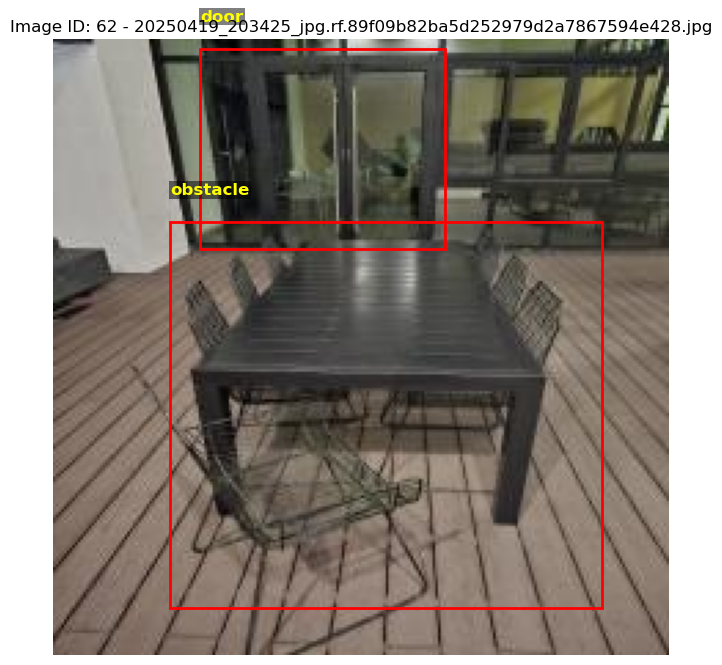

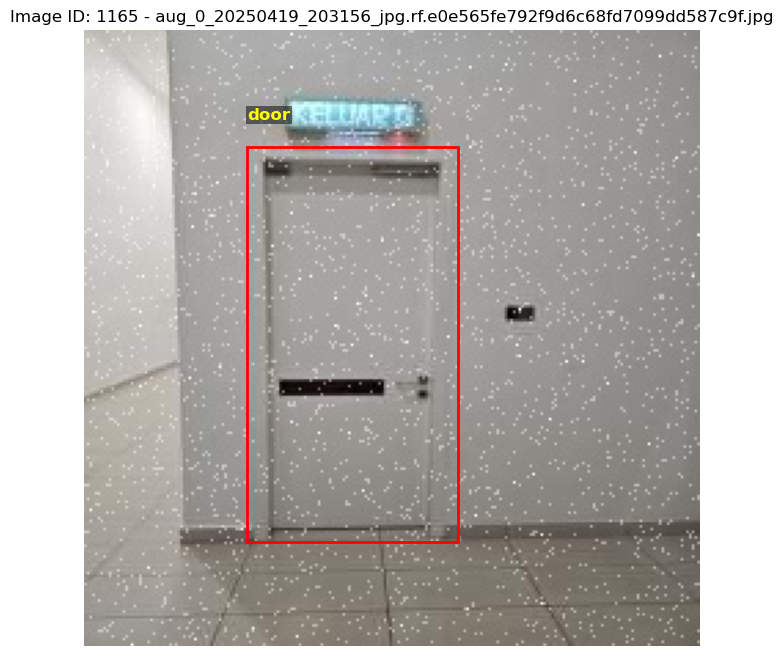

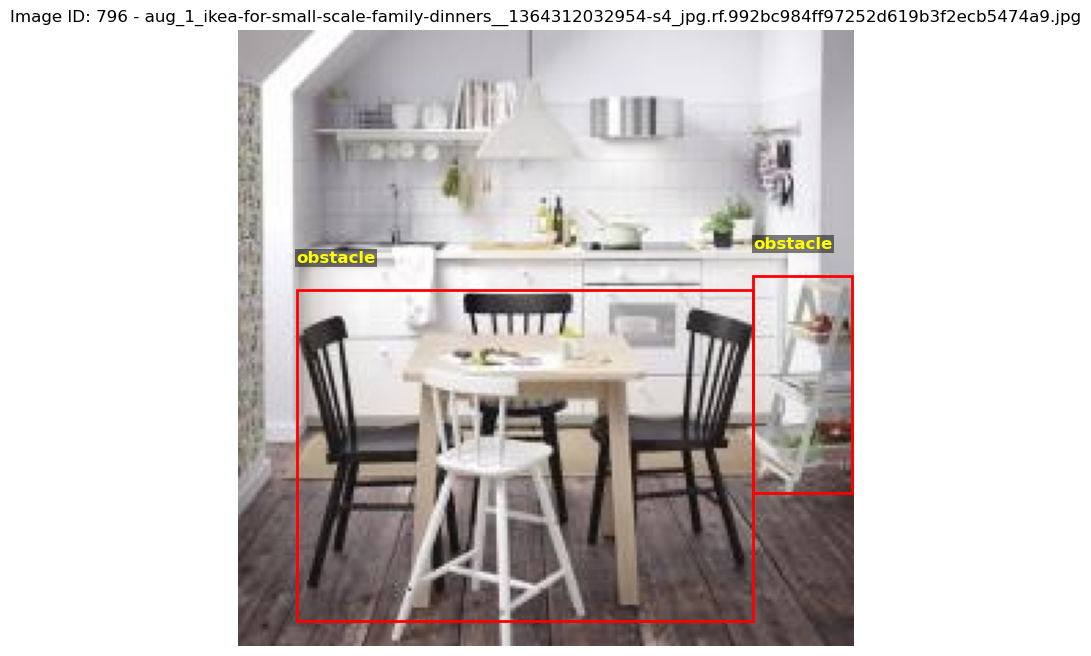

In [16]:
import numpy as np

# Visualizar 3 imágenes aumentadas con sus bboxes
def visualize_augmentations(json_path, images_dir, num_images=3):
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    # Crear mapeo de category_id -> nombre
    cat_map = {cat['id']: cat['name'] for cat in data['categories']}
    
    coco = COCO(json_path)
    img_ids = coco.getImgIds()
    
    sampled_ids = np.random.choice(img_ids, num_images, replace=False)
    
    for img_id in sampled_ids:
        img_info = coco.loadImgs(int(img_id))[0]
        img_path = os.path.join(images_dir, img_info['file_name'])
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        ann_ids = coco.getAnnIds(imgIds=int(img_id))
        anns = coco.loadAnns(ann_ids)
        
        plt.figure(figsize=(8, 8))
        plt.imshow(image)
        
        for ann in anns:
            bbox = ann['bbox']
            x, y, w, h = bbox
            rect = plt.Rectangle((x, y), w, h, fill=False, color='red', linewidth=2)
            plt.gca().add_patch(rect)
            
            # Obtener nombre de categoría en vez del ID
            cat_name = cat_map.get(ann['category_id'], f"ID:{ann['category_id']}")
            plt.text(x, y-10, cat_name, color='yellow', fontsize=12, weight='bold',
                    bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))
        
        plt.axis('off')
        plt.title(f"Image ID: {img_id} - {img_info['file_name']}")
        plt.show()

# Visualizar algunas imágenes aumentadas
visualize_augmentations(output_json, output_dir, num_images=3)


In [18]:
# Filtrado final de las clases que se van a mantener (según el EDA) 
import json
import os

# Función de filtrado y análisis
def filter_and_analyze(json_path, output_path, keep_names):
    with open(json_path, 'r') as f:
        data = json.load(f)

    print(f"📊 Analizando dataset: {os.path.basename(json_path)}")
    
    # Mapa de categorías: {id: name} y {name: id}
    cat_id_to_name = {cat['id']: cat['name'] for cat in data['categories']}
    cat_name_to_id = {cat['name']: cat['id'] for cat in data['categories']}
    
    # 1. Análisis Inicial
    print("\n--- Conteo ANTES del filtrado ---")
    counts = {name: 0 for name in cat_name_to_id.keys()}
    for ann in data['annotations']:
        cat_name = cat_id_to_name.get(ann['category_id'])
        if cat_name in counts:
            counts[cat_name] += 1
            
    # Ordenar y mostrar
    for name, count in sorted(counts.items(), key=lambda item: item[1], reverse=True):
        print(f"   {name}: {count}")

    # 2. Filtrado
    print(f"\n🗑️ Filtrando... Conservando solo: {keep_names}")
    
    keep_ids = [cat_name_to_id[name] for name in keep_names if name in cat_name_to_id]
    
    new_annotations = []
    kept_image_ids = set()
    
    for ann in data['annotations']:
        if ann['category_id'] in keep_ids:
            new_annotations.append(ann)
            kept_image_ids.add(ann['image_id'])
            
    # Filtrar imágenes que ya no tienen anotaciones útiles
    new_images = [img for img in data['images'] if img['id'] in kept_image_ids]
    
    # Filtrar categorías en el JSON
    new_categories = [cat for cat in data['categories'] if cat['id'] in keep_ids]

    # 3. Análisis Final
    print("\n--- Conteo DESPUÉS del filtrado ---")
    final_counts = {name: 0 for name in keep_names}
    for ann in new_annotations:
        cat_name = cat_id_to_name[ann['category_id']]
        final_counts[cat_name] += 1
        
    for name, count in sorted(final_counts.items(), key=lambda item: item[1], reverse=True):
        print(f"   {name}: {count}")

    # Guardar
    final_data = {
        "info": data.get("info", {}),
        "licenses": data.get("licenses", []),
        "categories": new_categories,
        "images": new_images,
        "annotations": new_annotations
    }
    
    with open(output_path, 'w') as f:
        json.dump(final_data, f)
        
    print(f"\n✅ Guardado en: {output_path}")
    print(f"   Imágenes originales: {len(data['images'])} -> Finales: {len(new_images)}")
    print(f"   Se eliminaron {len(data['images']) - len(new_images)} imágenes vacías tras filtrar clases.")

In [21]:
# Ejecución del filtrado y análisis para el dataset de entrenamiento aumentado
print("\n🔍 Filtrado final del dataset aumentado...")
classes_to_keep = ["door", "footpath", "obstacle", "person"] 

input_json = os.path.join(base_dir, "Dataset", "train", "augmented_images", "train_aug.json")
output_json = os.path.join(base_dir, "Dataset", "train", "augmented_images", "train_final.json")

if os.path.exists(input_json):
    filter_and_analyze(input_json, output_json, classes_to_keep)
else:
    print("⚠️ No se encuentra el archivo de entrada.")


🔍 Filtrado final del dataset aumentado...
📊 Analizando dataset: train_aug.json

--- Conteo ANTES del filtrado ---
   obstacle: 1431
   footpath: 486
   person: 270
   door: 252
   escalator: 42
   wall: 42
   elevator: 24
   closed_door: 3
   footpath-wall-sign-obstacle: 0

🗑️ Filtrando... Conservando solo: ['door', 'footpath', 'obstacle', 'person']

--- Conteo DESPUÉS del filtrado ---
   obstacle: 1431
   footpath: 486
   person: 270
   door: 252

✅ Guardado en: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/train/augmented_images/train_final.json
   Imágenes originales: 1173 -> Finales: 1146
   Se eliminaron 27 imágenes vacías tras filtrar clases.


In [22]:
# Ejecución del filtrado y análisis para el dataset de validación limpio
print("\n🔍 Filtrado final del dataset de validación limpio...")
classes_to_keep = ["door", "footpath", "obstacle", "person"] 

input_json = os.path.join(base_dir, "Dataset", "valid", "val_clean.json")
output_json = os.path.join(base_dir, "Dataset", "valid", "val_final.json")

if os.path.exists(input_json):
    filter_and_analyze(input_json, output_json, classes_to_keep)
else:
    print("⚠️ No se encuentra el archivo de entrada.")


🔍 Filtrado final del dataset de validación limpio...
📊 Analizando dataset: val_clean.json

--- Conteo ANTES del filtrado ---
   obstacle: 118
   footpath: 29
   door: 21
   person: 4
   footpath-wall-sign-obstacle: 0
   closed_door: 0
   elevator: 0
   escalator: 0
   wall: 0

🗑️ Filtrando... Conservando solo: ['door', 'footpath', 'obstacle', 'person']

--- Conteo DESPUÉS del filtrado ---
   obstacle: 118
   footpath: 29
   door: 21
   person: 4

✅ Guardado en: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/valid/val_final.json
   Imágenes originales: 85 -> Finales: 85
   Se eliminaron 0 imágenes vacías tras filtrar clases.


In [23]:
# Ejecución del filtrado y análisis para el dataset de test limpio
print("\n🔍 Filtrado final del dataset de test limpio...")
classes_to_keep = ["door", "footpath", "obstacle", "person"] 

input_json = os.path.join(base_dir, "Dataset", "test", "test_clean.json")
output_json = os.path.join(base_dir, "Dataset", "test", "test_final.json")

if os.path.exists(input_json):
    filter_and_analyze(input_json, output_json, classes_to_keep)
else:
    print("⚠️ No se encuentra el archivo de entrada.")


🔍 Filtrado final del dataset de test limpio...
📊 Analizando dataset: test_clean.json

--- Conteo ANTES del filtrado ---
   obstacle: 105
   footpath: 55
   door: 40
   person: 15
   escalator: 2
   wall: 1
   footpath-wall-sign-obstacle: 0
   closed_door: 0
   elevator: 0

🗑️ Filtrando... Conservando solo: ['door', 'footpath', 'obstacle', 'person']

--- Conteo DESPUÉS del filtrado ---
   obstacle: 105
   footpath: 55
   door: 40
   person: 15

✅ Guardado en: /Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/test/test_final.json
   Imágenes originales: 84 -> Finales: 84
   Se eliminaron 0 imágenes vacías tras filtrar clases.


In [30]:
# Función para graficar la distribución de clases
def plot_class_distribution(json_path, title="Distribución de Clases"):
    """
    Grafica la distribución de clases en un archivo JSON formato COCO.
    
    Args:
        json_path (str): Ruta al archivo JSON con anotaciones
        title (str): Título del gráfico
    """
    with open(json_path, 'r') as f:
        data = json.load(f)
    
    # Crear mapeo de categorías
    cat_id_to_name = {cat['id']: cat['name'] for cat in data['categories']}
    
    # Contar anotaciones por categoría
    counts = {name: 0 for name in cat_id_to_name.values()}
    for ann in data['annotations']:
        cat_name = cat_id_to_name.get(ann['category_id'])
        if cat_name in counts:
            counts[cat_name] += 1
    
    # Ordenar por cantidad
    sorted_counts = dict(sorted(counts.items(), key=lambda item: item[1], reverse=True))
    
    # Calcular total para porcentajes
    total = sum(counts.values())
    
    # Paleta de colores atractiva usando seaborn
    colors = sns.color_palette("magma", len(sorted_counts))
    
    # Crear gráfico
    plt.figure(figsize=(10, 6))
    bars = plt.bar(sorted_counts.keys(), sorted_counts.values(), color=colors, edgecolor='black', alpha=0.8)
    
    # Añadir valores y porcentajes sobre las barras
    for bar, (name, count) in zip(bars, sorted_counts.items()):
        height = bar.get_height()
        percentage = (count / total * 100) if total > 0 else 0
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}\n({percentage:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    plt.xlabel('Clase', fontsize=12, fontweight='bold')
    plt.ylabel('Número de Anotaciones', fontsize=12, fontweight='bold')
    plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    # Mostrar resumen
    print(f"\n📊 Resumen de distribución:")
    print(f"   Total de anotaciones: {total}")
    print(f"   Total de imágenes: {len(data['images'])}")
    for name, count in sorted_counts.items():
        percentage = (count / total * 100) if total > 0 else 0
        print(f"   {name}: {count} ({percentage:.1f}%)")

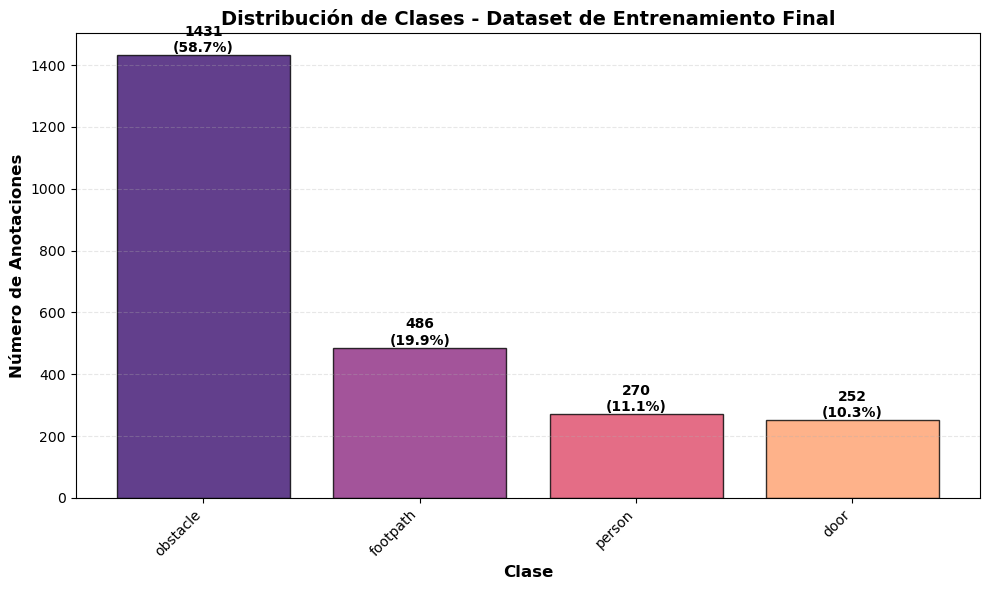


📊 Resumen de distribución:
   Total de anotaciones: 2439
   Total de imágenes: 1146
   obstacle: 1431 (58.7%)
   footpath: 486 (19.9%)
   person: 270 (11.1%)
   door: 252 (10.3%)


In [31]:
# Graficar distribución de clases en train_final.json
train_final_json = os.path.join(base_dir, "Dataset", "train", "augmented_images", "train_final.json")

if os.path.exists(train_final_json):
    plot_class_distribution(train_final_json, title="Distribución de Clases - Dataset de Entrenamiento Final")
else:
    print("⚠️ No se encuentra train_final.json")

**Análisis:**

El balance de clases muestra que hay dominio de la clase `obstacle` con el 58.7% de las anotaciones, mientras que `footpath` representa el 19.9% , `person` el 11.1% y `door` el 10.3%. Este desbalance puede afectar la capacidad del modelo para generalizar en clases menos representadas. Para mitigar esto se requiere el uso de penalizaciones en la función de pérdida durante el entrenamiento, asignando mayor peso a las clases minoritarias. Además, se debe monitorear métricas específicas por clase para asegurar un rendimiento equilibrado.

# Re-procesado

**Objetivo:** aplicar *Targeted Augmentation* y *Paste Augmentation* para compensar el desbalance entre `obstacle`, `door`, `person` y `footpath`.

**Estrategia:**
- **Oversampling selectivo:** mayor agresividad en imágenes que contienen clases minoritarias.
- **Aumento de contexto:** ruido gaussiano, blur progresivo, cambios de iluminación y color.
- **Paste Augmentation:** copiar objetos minoritarios y pegarlos en fondos con clase mayoritaria.

**Salida esperada:**
- Imágenes aumentadas en `./01_ING_DATOS/Dataset/train/augmented2_images`
- Anotaciones COCO en `train_final2.json`

In [ ]:
!pip install albumentations opencv-python

In [ ]:
import os
import sys

reprocess_src = os.path.join(base_dir, "src")
if reprocess_src not in sys.path:
    sys.path.append(reprocess_src)

from utils_coco_reprocess import targeted_augmentation
from utils_coco_plot import plot_class_distribution
from utils_coco_viz import visualize_coco_samples

In [8]:
# Rutas y parámetros
train_clean_path = os.path.join(base_dir, "Dataset", "train", "train_clean.json")
train_images_dir = os.path.join(base_dir, "Dataset", "train")
output_dir = os.path.join(base_dir, "Dataset", "train", "augmented2_images")
output_json = os.path.join(output_dir, "train_final2.json")

classes_to_keep = ["obstacle", "door", "person", "footpath"]

if os.path.exists(train_clean_path):
    summary = targeted_augmentation(
        input_json=train_clean_path,
        images_dir=train_images_dir,
        output_dir=output_dir,
        output_json=output_json,
        keep_names=classes_to_keep,
        mild_multiplier=1,
        aggressive_multiplier=3,
        enable_paste=True,
        paste_per_image=1,
        paste_max_objects=2,
        seed=42,
    )
    print("✅ Re-procesado completado")
    print(summary)
else:
    print("❌ No se encontró train_clean.json. Ejecuta la Fase 1 primero.")

/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/src/utils_coco_reprocess.py:73: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(p=0.6, var_limit=(10.0, 30.0)),
/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/env/lib/python3.10/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/src/utils_coco_reprocess.py:103: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(p=0.7, var_limit=(15.0, 50.0)),


✅ Re-procesado completado
{'majority_class': 'obstacle', 'minority_classes': 'door,person,footpath', 'original_images': 382, 'final_images': 1371, 'final_annotations': 3236}


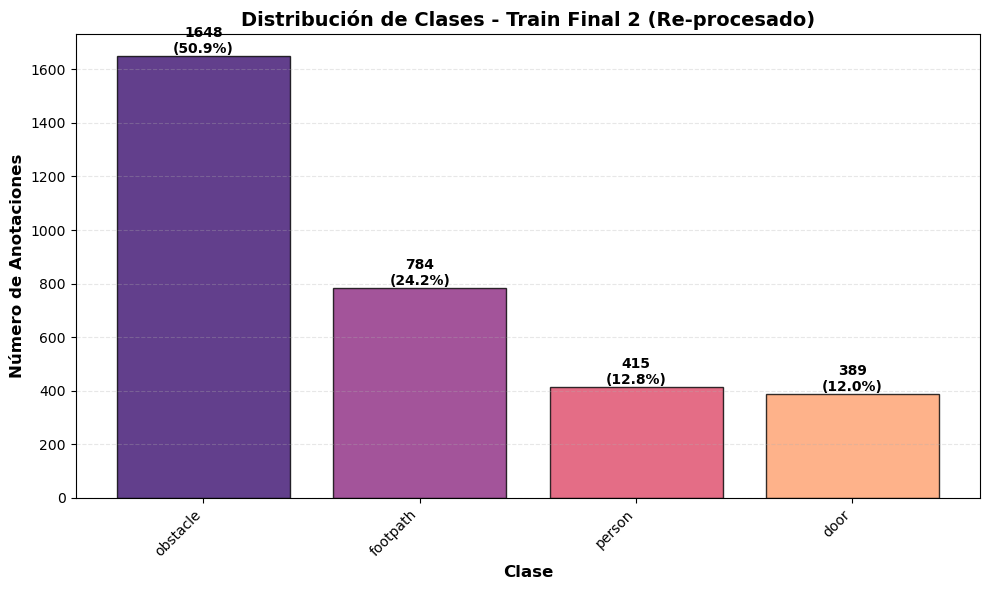

In [9]:
# Distribución final de clases tras el re-procesado
if os.path.exists(output_json):
    plot_class_distribution(output_json, title="Distribución de Clases - Train Final 2 (Re-procesado)")
else:
    print("⚠️ No se encuentra train_final2.json")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


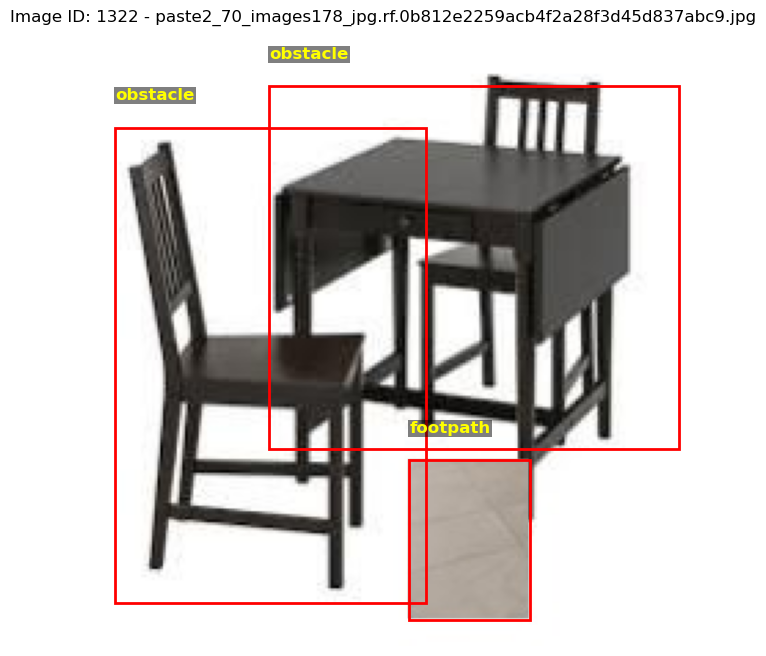

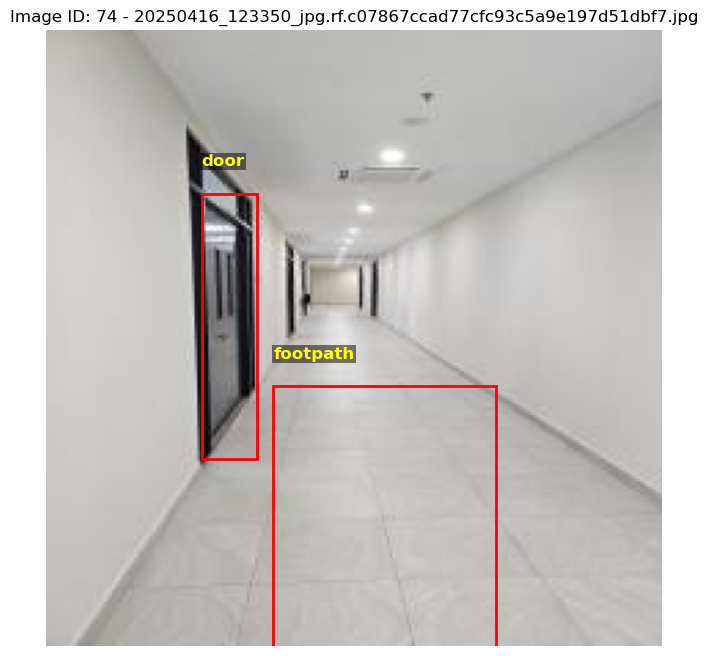

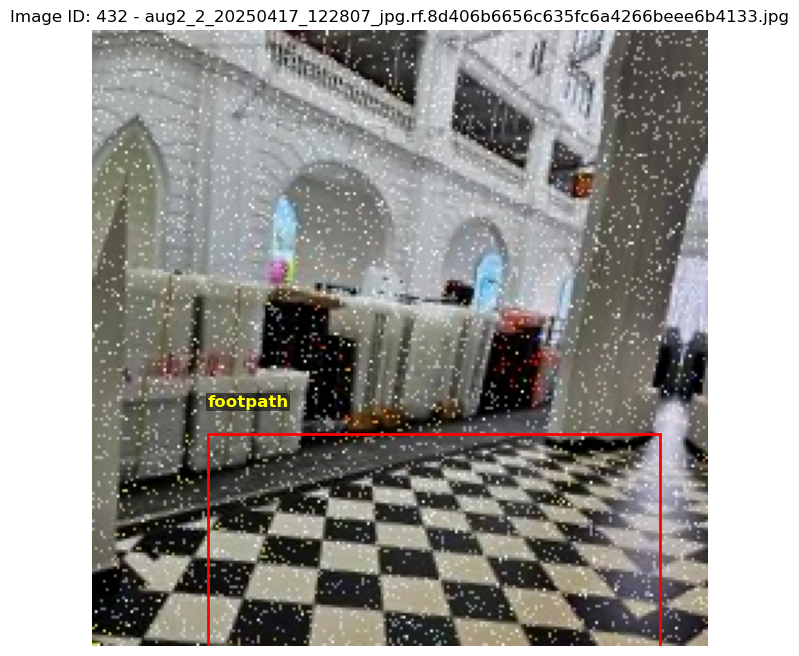

In [13]:
# Validación visual de muestras con bboxes
from utils_coco_viz import visualize_coco_samples

if os.path.exists(output_json):
    visualize_coco_samples(
        json_path=output_json,
        images_dir=output_dir,
        num_images=3,
        seed=42,
        class_filter=classes_to_keep,
    )
else:
    print("⚠️ No se encuentra train_final2.json")

# Fase 3: Generación de Data Loaders de TensorFlow

**Objetivo:** Crear la interfaz de carga eficiente optimizada para TensorFlow.

Actividades:
* **Función de Carga:** Desarrollar `get_dataset(json_path, images_dir)` para parsear el JSON COCO.
* **Conversión a Tensores:** Transformar datos crudos en tensores estructurados: `(image, bounding_box, class_id)`.
* **Optimización:** Implementar este paso para asegurar que arquitecturas como **MobileNet** puedan consumir los datos de forma fluida durante las épocas de entrenamiento.

In [ ]:
# Validación de las librerías a importar
import tensorflow as tf
import json
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [ ]:
# Función para cargar datos desde JSON COCO 
def load_coco_data(json_path):
    """Parsea el JSON y extrae listas de rutas y anotaciones."""
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Mapa image_id -> file_name
    img_map = {img['id']: img['file_name'] for img in data['images']}
    
    # Agrupar anotaciones por imagen
    # Estructura: {path: {'bboxes': [[y,x,h,w]...], 'classes': [0, 2...]}}
    samples = {}
    
    for ann in data['annotations']:
        img_id = ann['image_id']
        file_name = img_map.get(img_id)
        
        if not file_name: continue
        
        # COCO es [x, y, w, h] -> TF prefiere [y_min, x_min, y_max, x_max] normalizado
        # Pero para visualización simple usaremos coordenadas absolutas de píxeles [x, y, x+w, y+h]
        bbox = ann['bbox']
        x, y, w, h = bbox
        
        # Obtener nombre de clase y su ID numérico
        cat_id = ann['category_id']
        # Buscar el nombre en las categorías del JSON
        cat_name = next(c['name'] for c in data['categories'] if c['id'] == cat_id)
        class_idx = CLASS_MAP.get(cat_name)

        if class_idx is None: continue # Ignorar clases no listadas

        if file_name not in samples:
            samples[file_name] = {'bboxes': [], 'classes': []}
        
        samples[file_name]['bboxes'].append([x, y, x+w, y+h]) # x_min, y_min, x_max, y_max
        samples[file_name]['classes'].append(class_idx)

    # Convertir a listas para el generador
    img_paths = []
    bboxes_list = []
    classes_list = []

    for fname, content in samples.items():
        full_path = os.path.join(IMG_DIR, fname)
        if os.path.exists(full_path):
            img_paths.append(full_path)
            bboxes_list.append(content['bboxes'])
            classes_list.append(content['classes'])
            
    print(f"✅ Cargadas {len(img_paths)} imágenes válidas del JSON.")
    return img_paths, bboxes_list, classes_list

In [ ]:
# Función generadora TF.DATA
def data_generator(img_paths, bboxes, classes):
    """Generador que alimenta al tf.data.Dataset"""
    for path, box, cls in zip(img_paths, bboxes, classes):
        # Leer imagen
        img = cv2.imread(path)
        if img is None: continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = img / 255.0 # Normalizar 0-1
        
        # Padding de Cajas y Clases (para tener Tensores fijos)
        # Rellenamos con -1 o 0 hasta llegar a MAX_OBJECTS
        box_padded = np.zeros((MAX_OBJECTS, 4), dtype=np.float32)
        cls_padded = np.full((MAX_OBJECTS,), -1, dtype=np.int32) # -1 indica "sin objeto"
        
        n_obj = min(len(box), MAX_OBJECTS)
        if n_obj > 0:
            box_padded[:n_obj] = np.array(box)[:n_obj]
            cls_padded[:n_obj] = np.array(cls)[:n_obj]
            
        yield img, box_padded, cls_padded

# Función para crear el tf.data.Dataset
def get_tf_dataset(json_path):
    paths, bboxes, classes = load_coco_data(json_path)
    
    dataset = tf.data.Dataset.from_generator(
        lambda: data_generator(paths, bboxes, classes),
        output_signature=(
            tf.TensorSpec(shape=(IMG_SIZE, IMG_SIZE, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(MAX_OBJECTS, 4), dtype=tf.float32),
            tf.TensorSpec(shape=(MAX_OBJECTS,), dtype=tf.int32)
        )
    )
    
    return dataset.batch(BATCH_SIZE)

In [ ]:
# Función para visualizar un batch del dataset
def visualize_batch(dataset, output_file):
    print("🎨 Generando visualización de verificación...")
    
    # Obtener un solo batch
    for images, boxes, classes in dataset.take(1):
        plt.figure(figsize=(20, 20))
        
        # Mostrar primeras 9 imágenes del batch
        for i in range(min(9, BATCH_SIZE)):
            ax = plt.subplot(3, 3, i + 1)
            img = images[i].numpy()
            
            # Des-normalizar para dibujar si es necesario, pero imshow maneja float 0-1
            # Dibujar cajas
            valid_indices = np.where(classes[i] != -1)[0]
            
            # Convertir imagen a formato OpenCV (uint8) para dibujar rectangulos fácil
            img_draw = (img * 255).astype(np.uint8).copy()
            
            for idx in valid_indices:
                x1, y1, x2, y2 = boxes[i][idx].numpy().astype(int)
                cls_id = int(classes[i][idx].numpy())
                label = CLASSES[cls_id]
                
                # Color basado en clase (hash simple)
                color = ((cls_id * 50) % 255, (cls_id * 100) % 255, (cls_id * 200) % 255)
                
                cv2.rectangle(img_draw, (x1, y1), (x2, y2), color, 2)
                cv2.putText(img_draw, label, (x1, y1-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
            
            plt.imshow(img_draw)
            plt.axis("off")
            plt.title(f"Sample {i}")
            
        plt.tight_layout()
        plt.savefig(output_file)
        print(f"✅ Visualización guardada en: {output_file}")
        plt.close()

In [ ]:
# --- CONFIGURACIÓN ---
BASE_DIR = "/Users/admin/Documents/TFM_UNIR/01_ING_DATOS/Dataset/train"
JSON_PATH = os.path.join(BASE_DIR, "augmented_images/train_final.json")
IMG_DIR = os.path.join(BASE_DIR, "augmented_images") # Donde están las imgs (orig + aug)

# Ajustes del Modelo
IMG_SIZE = 224
BATCH_SIZE = 16
MAX_OBJECTS = 50  # Rellenaremos con ceros si hay menos de 50 objetos por foto
CLASSES = ["door", "footpath", "obstacle", "person"]
CLASS_MAP = {name: i for i, name in enumerate(CLASSES)}

if os.path.exists(JSON_PATH):
    # Crear Dataset
    ds = get_tf_dataset(JSON_PATH)
        
    # Verificar y Guardar Imagen
    visualize_batch(ds, "dataset_verification.png")
else:
    print(f"❌ No se encontró el JSON: {JSON_PATH}")

✅ Cargadas 1146 imágenes válidas del JSON.
🎨 Generando visualización de verificación...
✅ Visualización guardada en: dataset_verification.png


2026-01-30 23:45:31.172318: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


# Síntesis y Resultados del Preprocesamiento de Datos

## Resumen de Actividades
Tras el Análisis Exploratorio de Datos (EDA), se ejecutó un flujo de ingeniería de datos orientado a mitigar la escasez de muestras y adaptar el dataset a las restricciones de hardware del ESP32-S3 y la arquitectura de tensores de TensorFlow.

| Fase | Descripción Técnica | Justificación e Impacto |
| :--- | :--- | :--- |
| **1. Limpieza Lógica (Data Cleaning)** | Eliminación de anotaciones con área $< 225 px^2$ (ruido) y $> 95\%$ de la imagen (outliers). | Se reduce la confusión del modelo eliminando objetos irrelevantes para la navegación o errores de etiquetado manual. |
| **2. Aumento de Datos (Data Augmentation)** | Generación sintética *offline* (x3) mediante `HorizontalFlip`, `RandomBrightness` y `GaussianNoise`. | Se triplicó el dataset de entrenamiento (~390 $\to$ 1146 imágenes) para evitar *overfitting* y simular el ruido del sensor OV2640. |
| **3. Filtrado Semántico de Clases** | Restricción del dominio a 4 clases funcionales: `door`, `footpath`, `obstacle`, `person`. | Focalización del aprendizaje en objetos críticos para la navegación autónoma, eliminando clases con representatividad nula. |
| **4. Ingeniería de Tensores (Pipeline)** | Implementación de `tf.data` con Padding Estático (`MAX_OBJECTS = 50`) y Normalización $[0, 1]$. | Garantiza tensores de forma fija ($B \times 50 \times 4$) requeridos para el procesamiento en batch en GPU/TPU. |

---

## Análisis de Distribución Post-Procesamiento

El dataset final resultante presenta una distribución de clases que condicionará la estrategia de entrenamiento:

* **Clase Mayoritaria:** `obstacle` domina el dataset con un **58.7%** de las instancias.
* **Clases Minoritarias:** `person` y `door` representan apenas el **~10%** cada una.
* **Densidad:** Se mantiene una densidad baja-media, cubierta holgadamente por el límite de 50 objetos por imagen.

**Conclusión del Estado de los Datos:**
El dataset está limpio, es consistente geométricamente y tiene un volumen aceptable para *Transfer Learning*. Sin embargo, presenta un **desbalance severo** que no se corrigió mediante *Augmentation* (ya que este fue uniforme), lo que introduce un riesgo de sesgo hacia la clase `obstacle`.

---

## Acciones Críticas para la Fase de Modelado

Basado en la síntesis anterior, se definen los siguientes requisitos obligatorios para la etapa de diseño de arquitectura y entrenamiento:

1.  **Implementación de Class Weights:** Es imperativo calcular y aplicar pesos a la función de pérdida (*Loss Function*) durante el entrenamiento (`model.fit`). Se debe penalizar más el error en `person` y `door` para contrarrestar su baja frecuencia frente a `obstacle`.
2.  **Métrica de Evaluación Ponderada:** No se debe confiar únicamente en el *Accuracy* global. Se monitorizará el **mAP (mean Average Precision) por clase** para asegurar que el modelo detecta las clases minoritarias.
3.  **Configuración de Anchors (Si aplica):** Para modelos como MobileNet-SSD o YOLO, los *anchor boxes* deben calibrarse considerando que eliminamos los objetos minúsculos ($<15 \times 15 px$).
4.  **Transfer Learning:** Dado que incluso con aumento tenemos < 2000 imágenes, el entrenamiento desde cero (*from scratch*) es inviable. Se utilizarán pesos pre-entrenados de 3 modelos diferentes, congelando las capas base inicialmente. ^Sujeto a pruebas